# Full Preliminary Analysis

Runs the complete NHS A&E pipeline end-to-end:  
**Build dataset → Clean & prepare → Data audit → Shock detection → Resilience scoring → Trust clustering**

Run cells in order. Intermediate datasets are saved to `data/` (gitignored). Raw `.xls` source files are in `data/17/`, `data/18/`, `data/19/`.

In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")

# ── colour system ──────────────────────────────────────────────────────────────
C_BLUE    = "#2166AC"   # primary / neutral trend
C_RED     = "#D6404E"   # breach / shock / negative
C_GREEN   = "#4DAC26"   # target / positive
C_ORANGE  = "#E08B2C"   # secondary comparison
C_GRAY    = "#AAAAAA"   # baselines / reference
C_DARK    = "#2D2D2D"   # text accents

CLUSTER_COLORS   = [C_BLUE, C_RED, C_GREEN, C_ORANGE]
EVIDENCE_PALETTE = {"low": C_GRAY, "medium": C_BLUE, "high": C_GREEN}

# ── base theme ─────────────────────────────────────────────────────────────────
sns.set_theme(style="ticks")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#CCCCCC",
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         "#F0F0F0",
    "grid.linewidth":     0.7,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.titlepad":      10,
    "axes.labelsize":     10,
    "axes.labelcolor":    "#333333",
    "axes.labelpad":      6,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.color":        "#555555",
    "ytick.color":        "#555555",
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.major.width":  0.7,
    "ytick.major.width":  0.7,
    "legend.fontsize":    9,
    "legend.frameon":     False,
    "lines.linewidth":    2,
    "figure.figsize":     (12, 4.5),
    "figure.dpi":         110,
})

In [2]:
BASE_DIR   = Path(".").resolve()
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR.parent          # CSVs land beside the repo folder

FULL_PANEL_PATH     = OUTPUT_DIR / "ae_2017_2019_full_panel.csv"
ANALYSIS_READY_PATH = OUTPUT_DIR / "ae_2017_2019_analysis_ready.csv"
WITH_SHOCKS_PATH    = OUTPUT_DIR / "ae_2017_2019_with_shocks.csv"
SHOCK_SUMMARY_PATH  = OUTPUT_DIR / "trust_shock_summary.csv"
RESILIENCE_PATH     = OUTPUT_DIR / "trust_resilience_scores.csv"
CLUSTERS_PATH       = OUTPUT_DIR / "trust_resilience_clusters.csv"

# shared pipeline parameters
ROLLING_WINDOW   = 12
MIN_PERIODS      = 6
ZSCORE_THRESHOLD = 2.0    # raised from 1.5: z≥1.5 shocks showed no significant breach impact (p=0.61)
RATIO_THRESHOLD  = 1.15
SHRINKAGE_K      = 5
N_CLUSTERS       = 3      # after provider filtering, silhouette prefers k=3 (0.473 vs 0.411 for k=2)
RANDOM_STATE     = 42

## 1. Build Dataset

Reads all `.xls` files from `data/17/`, `data/18/`, `data/19/`, extracts eight key columns per provider-month, and saves the unified panel.

In [3]:
month_map = {
    "jan": "01", "feb": "02", "mar": "03", "apr": "04",
    "may": "05", "jun": "06", "jul": "07", "aug": "08",
    "sep": "09", "oct": "10", "nov": "11", "dec": "12",
}

def clean_col(c):
    return str(c).lower().strip().replace("\n", " ")

def find_exact_col(raw_df, target):
    t = clean_col(target)
    for col in raw_df.columns:
        if clean_col(col) == t:
            return col
    return None

files = sorted(glob.glob(str(DATA_DIR / "**/*.xls"), recursive=True))
all_dfs = []

for file in files:
    filename = Path(file).name
    try:
        year      = "20" + filename[:2]
        month_str = filename[3:6].lower()
        file_month = pd.to_datetime(f"{year}-{month_map[month_str]}-01")

        raw = pd.read_excel(file, skiprows=15).dropna(axis=0, how="all")

        col_map = {
            "provider_code":  find_exact_col(raw, "Code"),
            "region":         find_exact_col(raw, "Region"),
            "provider_name":  find_exact_col(raw, "Name"),
            "att_total":      find_exact_col(raw, "Total attendances"),
            "pct_4hr_all":    find_exact_col(raw, "Percentage in 4 hours or less (all)"),
            "emerg_adm_total":find_exact_col(raw, "Total Emergency Admissions"),
            "wait_4hr_dta":   find_exact_col(raw, "Number of patients spending >4 hours from decision to admit to admission"),
            "wait_12hr_dta":  find_exact_col(raw, "Number of patients spending >12 hours from decision to admit to admission"),
        }
        missing = [k for k, v in col_map.items() if v is None]
        if missing:
            print(f"SKIPPED {filename}: missing {missing}")
            continue

        df_file = pd.DataFrame({k: raw[v] for k, v in col_map.items()})
        df_file["month"]       = file_month
        df_file["source_file"] = filename
        all_dfs.append(df_file)

    except Exception as e:
        print(f"ERROR {filename}: {e}")

combined = pd.concat(all_dfs, ignore_index=True)
combined = combined[combined["provider_code"].notna() & combined["provider_name"].notna()].copy()

for col in ["provider_code", "region", "provider_name"]:
    combined[col] = combined[col].astype(str).str.strip()

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined.to_csv(FULL_PANEL_PATH, index=False)
print(f"Saved  {FULL_PANEL_PATH.name}  |  shape: {combined.shape}")
print(f"Files loaded: {len(all_dfs)} / {len(files)}")
print("\n4-hour performance (raw):")
print(combined["pct_4hr_all"].describe().round(3))

Saved  ae_2017_2019_full_panel.csv  |  shape: (8639, 10)
Files loaded: 36 / 36

4-hour performance (raw):
count    8125.000
mean        0.913
std         0.088
min         0.547
25%         0.848
50%         0.931
75%         0.999
max         1.000
Name: pct_4hr_all, dtype: float64


## 2. Prepare Analysis Dataset

Removes aggregate rows, standardises 4-hour performance to 0–1, and derives breach rate, admission rate, and 12-hour wait rate.

**Provider type filter:** Walk-in centres, GP-led services, and minor injury units are excluded. These are identified by two criteria: (1) `Y0`-prefix provider codes (GP/walk-in services confirmed from NHS data), and (2) providers where ≥ 80 % of months report exactly 100 % compliance — a near-impossible result for full acute A&E departments, indicating a fundamentally different case-mix that makes breach-based resilience scoring meaningless.

In [4]:
df = pd.read_csv(FULL_PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["provider_code", "month"])

df = df[~df["provider_name"].str.contains("total", case=False, na=False)].copy()

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["att_total"])
df_analysis = df.dropna(subset=["pct_4hr_all"]).copy()

if df_analysis["pct_4hr_all"].max() > 1:
    df_analysis["pct_4hr_all"] = df_analysis["pct_4hr_all"] / 100

df_analysis["four_hour_breach_rate"] = 1 - df_analysis["pct_4hr_all"]
df_analysis["admission_rate"]        = df_analysis["emerg_adm_total"] / df_analysis["att_total"]
df_analysis["wait_12hr_rate"]        = df_analysis["wait_12hr_dta"]   / df_analysis["att_total"]

# ── Provider type filter ───────────────────────────────────────────────────────
n_before = df_analysis["provider_code"].nunique()

# Y0-prefix = GP-led / walk-in centres
y0_codes = df_analysis[df_analysis["provider_code"].str.startswith("Y0")]["provider_code"].unique()
df_analysis = df_analysis[~df_analysis["provider_code"].str.startswith("Y0")].copy()

# Providers with ≥80% of months at exactly 100% compliance are not acute A&E
perfect_share = (
    df_analysis.groupby("provider_code")["pct_4hr_all"]
    .apply(lambda x: (x == 1.0).mean())
)
always_perfect = perfect_share[perfect_share >= 0.8].index
df_analysis = df_analysis[~df_analysis["provider_code"].isin(always_perfect)].copy()

n_after = df_analysis["provider_code"].nunique()
print(f"Provider filter: {n_before} → {n_after} providers")
print(f"  Removed {len(y0_codes)} Y0-prefix (GP/walk-in), {len(always_perfect)} always-perfect (MIU/community)")

df_analysis.to_csv(ANALYSIS_READY_PATH, index=False)
print(f"\nSaved  {ANALYSIS_READY_PATH.name}  |  shape: {df_analysis.shape}")
print(f"Date range : {df_analysis['month'].min().date()} → {df_analysis['month'].max().date()}")
print(f"Providers  : {df_analysis['provider_code'].nunique()}")
print("\nMissing values:")
print(df_analysis[["att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]].isna().sum())

Provider filter: 270 → 200 providers
  Removed 32 Y0-prefix (GP/walk-in), 38 always-perfect (MIU/community)

Saved  ae_2017_2019_analysis_ready.csv  |  shape: (6537, 13)
Date range : 2017-01-01 → 2019-12-01
Providers  : 200

Missing values:
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64


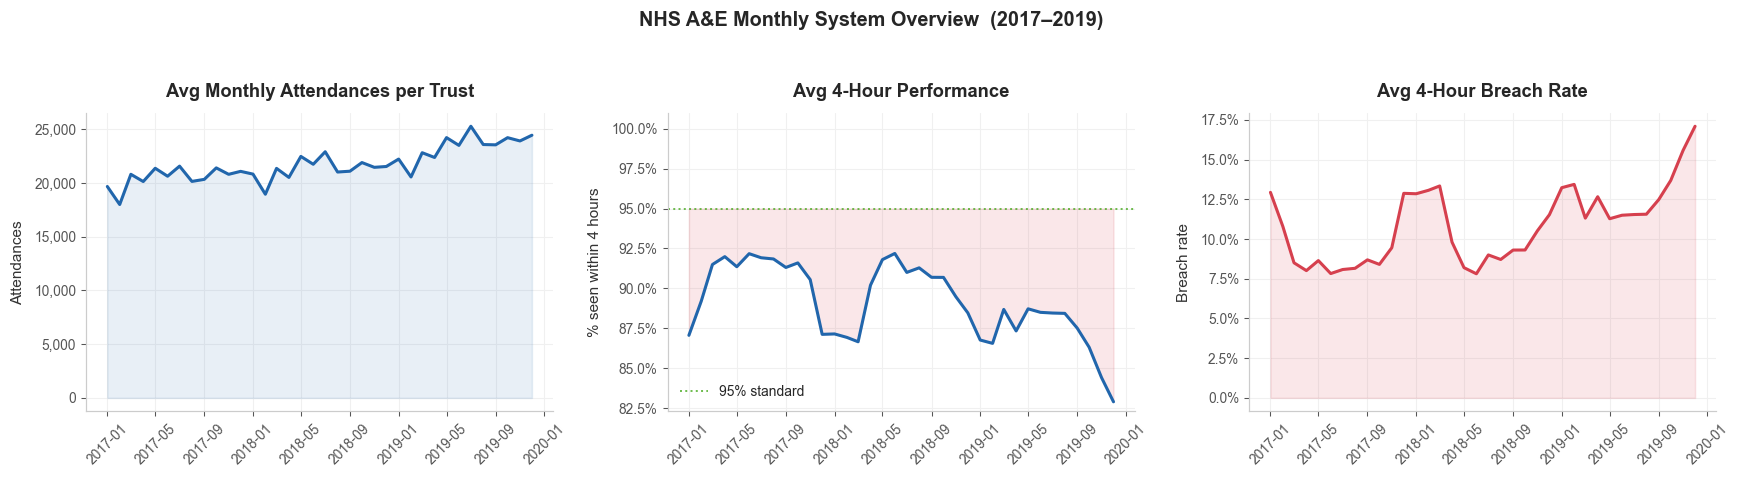

In [5]:
monthly = (
    df_analysis.groupby("month")[
        ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("NHS A&E Monthly System Overview  (2017–2019)",
             fontsize=13, fontweight="bold", y=1.03)

# ── Attendances ──
ax = axes[0]
ax.fill_between(monthly["month"], monthly["att_total"], alpha=0.1, color=C_BLUE)
ax.plot(monthly["month"], monthly["att_total"], color=C_BLUE)
ax.set_title("Avg Monthly Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── 4-hour performance with 95% target and breach fill ──
ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly["month"], monthly["pct_4hr_all"], 0.95,
    where=monthly["pct_4hr_all"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly["month"], monthly["pct_4hr_all"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

# ── Breach rate ──
ax = axes[2]
ax.fill_between(monthly["month"], monthly["four_hour_breach_rate"], alpha=0.12, color=C_RED)
ax.plot(monthly["month"], monthly["four_hour_breach_rate"], color=C_RED)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Avg 4-Hour Breach Rate")
ax.set_ylabel("Breach rate")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")

fig.tight_layout()
plt.show()

## 3. Data Audit

Checks for missing values, impossible 4-hour performance values, and panel balance (months observed per provider).

In [6]:
print("=== Missing values ===")
print(df_analysis[
    ["provider_code", "provider_name", "month",
     "att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]
].isna().sum())

print("\n=== Impossible 4-hour performance values (outside [0, 1]) ===")
bad = df_analysis[(df_analysis["pct_4hr_all"] < 0) | (df_analysis["pct_4hr_all"] > 1)]
print(f"Count: {len(bad)}")
if len(bad):
    print(bad[["provider_code", "provider_name", "month", "pct_4hr_all"]].head())

print("\n=== Panel balance: months observed per provider ===")
print(df_analysis.groupby("provider_code")["month"].nunique().describe().round(1))

print("\n=== Top 10 providers by avg monthly attendances ===")
print(
    df_analysis.groupby(["provider_code", "provider_name"])["att_total"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .to_string(index=False)
)

=== Missing values ===
provider_code      0
provider_name      0
month              0
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64

=== Impossible 4-hour performance values (outside [0, 1]) ===
Count: 0

=== Panel balance: months observed per provider ===
count    200.0
mean      32.7
std        7.6
min        3.0
25%       35.0
50%       36.0
75%       36.0
max       36.0
Name: month, dtype: float64

=== Top 10 providers by avg monthly attendances ===
provider_code                                                 provider_name    att_total
            -                                                       England 2.047354e+06
          R1H                                        Barts Health NHS Trust 4.182692e+04
          R0A                    Manchester University NHS Foundation Trust 3.466959e+04
          RW6                             Pennine Acute Hospitals NHS Trust 3.171697e+04
          R1K             London North West Un

## 4. Shock Detection

A **demand shock** is a month where a trust's attendances exceed its own rolling 12-month baseline by ≥ **2.0 SD** (raised from 1.5 — the original threshold produced 914 shock-months with a mean breach impact of +0.00057 pp, p = 0.61, indistinguishable from zero). The rolling baseline is lagged one month to prevent look-ahead bias.

**Merger handling:** NHS trust mergers create spurious z > 10 attendance spikes because a newly combined trust reports multi-site volumes against a single-site rolling baseline. Each provider code is split into independent series at each name change (merger signal), so pre- and post-merger periods have separate baselines. Structural break months (z > 10) are additionally excluded from the shock flag.

In [7]:
df_shock = pd.read_csv(ANALYSIS_READY_PATH)
df_shock["month"] = pd.to_datetime(df_shock["month"])

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df_shock[col] = pd.to_numeric(df_shock[col], errors="coerce")

df_shock = df_shock.dropna(subset=["att_total", "pct_4hr_all"]).copy()
df_shock = df_shock[
    (df_shock["provider_code"] != "-") &
    (~df_shock["provider_name"].str.contains("england", case=False, na=False))
].copy()
df_shock = df_shock.sort_values(["provider_code", "month"]).copy()

# ── Merger handling: split series at trust name changes ────────────────────────
# A new name for the same provider_code signals an NHS merger or restructure.
# Pre- and post-merger periods get independent rolling baselines via series_id.
df_shock["_name_seq"] = df_shock.groupby("provider_code")["provider_name"].transform(
    lambda x: (x != x.shift(1)).cumsum()
)
df_shock["series_id"] = df_shock["provider_code"] + "_s" + df_shock["_name_seq"].astype(str)
df_shock = df_shock.drop(columns=["_name_seq"])
n_splits = (df_shock.groupby("provider_code")["series_id"].nunique() > 1).sum()
print(f"Provider codes split into ≥2 series (mergers): {n_splits}")

# derived metrics
df_shock["four_hour_breach_rate"] = 1 - df_shock["pct_4hr_all"]
df_shock["admission_rate"]        = df_shock["emerg_adm_total"] / df_shock["att_total"]
df_shock["wait_4hr_rate"]         = df_shock["wait_4hr_dta"]    / df_shock["att_total"]
df_shock["wait_12hr_rate"]        = df_shock["wait_12hr_dta"]   / df_shock["att_total"]

# rolling demand baseline (lagged 1 month) — grouped by series_id, not provider_code
grp = df_shock.groupby("series_id")["att_total"]
df_shock["att_rolling_mean"]      = grp.transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
df_shock["att_rolling_std"]       = grp.transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std())
df_shock["demand_ratio"]          = df_shock["att_total"] / df_shock["att_rolling_mean"]
df_shock["demand_zscore"]         = (df_shock["att_total"] - df_shock["att_rolling_mean"]) / df_shock["att_rolling_std"]
df_shock["demand_zscore_capped"]  = df_shock["demand_zscore"].clip(-5, 5)
df_shock["structural_break_flag"] = df_shock["demand_zscore"] > 10

# shock flags — structural break months excluded from canonical shock flag
df_shock["shock_ratio"]  = df_shock["demand_ratio"]  >= RATIO_THRESHOLD
df_shock["shock_zscore"] = df_shock["demand_zscore"] >= ZSCORE_THRESHOLD
df_shock["shock"]        = df_shock["shock_zscore"] & ~df_shock["structural_break_flag"]

# month-on-month performance changes (per series)
df_shock["breach_change"]    = df_shock.groupby("series_id")["four_hour_breach_rate"].diff()
df_shock["perf_change"]      = df_shock.groupby("series_id")["pct_4hr_all"].diff()
df_shock["wait_12hr_change"] = df_shock.groupby("series_id")["wait_12hr_rate"].diff()

df_shock.to_csv(WITH_SHOCKS_PATH, index=False)
print(f"Saved  {WITH_SHOCKS_PATH.name}  |  shape: {df_shock.shape}")

Provider codes split into ≥2 series (mergers): 13
Saved  ae_2017_2019_with_shocks.csv  |  shape: (6483, 27)


In [8]:
print(f"Shock share  z-score (z≥{ZSCORE_THRESHOLD}) : {df_shock['shock_zscore'].mean():.1%}  ({int(df_shock['shock_zscore'].sum())} months)")
print(f"Shock share  canonical (excl. breaks): {df_shock['shock'].mean():.1%}  ({int(df_shock['shock'].sum())} months)")
print(f"Shock share  ratio                   : {df_shock['shock_ratio'].mean():.1%}  ({int(df_shock['shock_ratio'].sum())} months)")
print(f"\nDefinition overlap:")
print(pd.crosstab(df_shock["shock_ratio"], df_shock["shock"],
                  rownames=["Ratio shock"], colnames=["Z-score canonical"]))
print(f"\nStructural breaks excluded (z > 10) : {int(df_shock['structural_break_flag'].sum())}")
print(f"Series with ≥1 shock                : {int((df_shock.groupby('series_id')['shock'].sum() > 0).sum())}")

shock_summary = (
    df_shock[df_shock["shock"]]
    .groupby(["provider_code", "provider_name"])
    .agg(
        shock_months       = ("shock", "sum"),
        avg_demand_ratio   = ("demand_ratio", "mean"),
        avg_breach_change  = ("breach_change", "mean"),
        avg_wait_12hr_rate = ("wait_12hr_rate", "mean"),
        avg_attendances    = ("att_total", "mean"),
    )
    .reset_index()
    .sort_values("avg_breach_change", ascending=False)
)
shock_summary.to_csv(SHOCK_SUMMARY_PATH, index=False)

print(f"\nTop 10 fragile trusts during shocks (largest 4-hr breach deterioration):")
print(
    shock_summary[shock_summary["shock_months"] >= 2]
    .head(10)[["provider_name", "shock_months", "avg_demand_ratio", "avg_breach_change"]]
    .to_string(index=False)
)

Shock share  z-score (z≥2.0) : 5.7%  (367 months)
Shock share  canonical (excl. breaks): 5.5%  (358 months)
Shock share  ratio                   : 5.3%  (344 months)

Definition overlap:
Z-score canonical  False  True 
Ratio shock                    
False               5908    231
True                 217    127

Structural breaks excluded (z > 10) : 9
Series with ≥1 shock                : 163

Top 10 fragile trusts during shocks (largest 4-hr breach deterioration):
                                                 provider_name  shock_months  avg_demand_ratio  avg_breach_change
Barking, Havering And Redbridge University Hospitals NHS Trust             2          1.109072           0.048269
                     Alder Hey Children's NHS Foundation Trust             2          1.195583           0.046551
         James Paget University Hospitals NHS Foundation Trust             2          1.142287           0.035939
                             The Royal Wolverhampton NHS Trust          

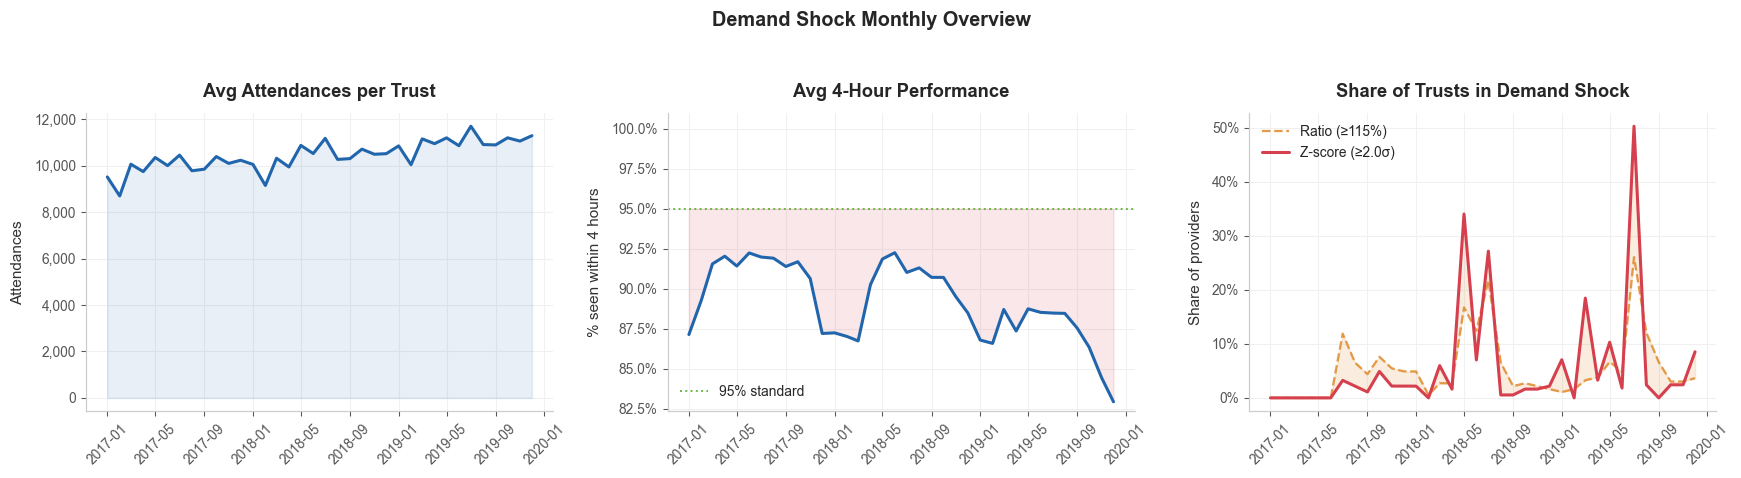

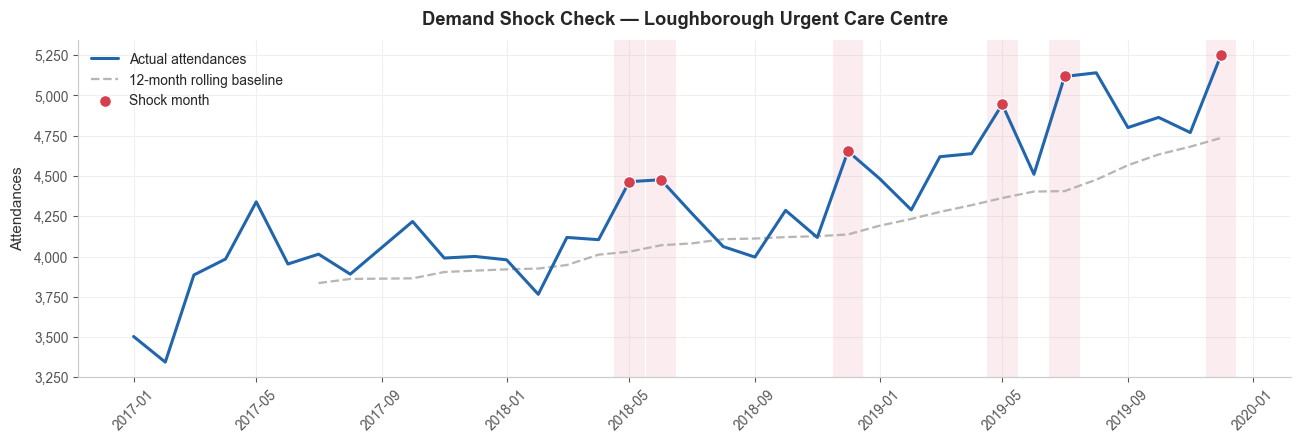

In [9]:
monthly_shock = (
    df_shock.groupby("month")
    .agg(
        avg_att            = ("att_total", "mean"),
        avg_4hr            = ("pct_4hr_all", "mean"),
        shock_ratio_share  = ("shock_ratio", "mean"),
        shock_zscore_share = ("shock_zscore", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("Demand Shock Monthly Overview", fontsize=13, fontweight="bold", y=1.03)

# ── Attendances ──
ax = axes[0]
ax.fill_between(monthly_shock["month"], monthly_shock["avg_att"], alpha=0.1, color=C_BLUE)
ax.plot(monthly_shock["month"], monthly_shock["avg_att"], color=C_BLUE)
ax.set_title("Avg Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── 4-hour performance ──
ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly_shock["month"], monthly_shock["avg_4hr"], 0.95,
    where=monthly_shock["avg_4hr"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly_shock["month"], monthly_shock["avg_4hr"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

# ── Shock definition comparison ──
ax = axes[2]
ax.fill_between(
    monthly_shock["month"],
    monthly_shock["shock_ratio_share"],
    monthly_shock["shock_zscore_share"],
    alpha=0.15, color=C_ORANGE,
)
ax.plot(monthly_shock["month"], monthly_shock["shock_ratio_share"],
        color=C_ORANGE, linewidth=1.5, linestyle="--",
        label=f"Ratio (≥{RATIO_THRESHOLD:.0%})", alpha=0.85)
ax.plot(monthly_shock["month"], monthly_shock["shock_zscore_share"],
        color=C_RED, label=f"Z-score (≥{ZSCORE_THRESHOLD}σ)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Share of Trusts in Demand Shock")
ax.set_ylabel("Share of providers")
ax.legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

# ── Individual trust: most shock months ──
shock_counts = df_shock.groupby("provider_code")["shock"].sum()
if shock_counts.max() > 0:
    top_code   = shock_counts.idxmax()
    sample     = df_shock[df_shock["provider_code"] == top_code].copy()
    shock_rows = sample[sample["shock"]]

    fig, ax = plt.subplots(figsize=(12, 4.2))

    # soft red band behind each shock month
    for _, row in shock_rows.iterrows():
        ax.axvspan(
            row["month"] - pd.Timedelta(days=15),
            row["month"] + pd.Timedelta(days=15),
            alpha=0.09, color=C_RED, linewidth=0,
        )

    ax.plot(sample["month"], sample["att_total"],
            color=C_BLUE, label="Actual attendances", zorder=3)
    ax.plot(sample["month"], sample["att_rolling_mean"],
            color=C_GRAY, linewidth=1.5, linestyle="--",
            label="12-month rolling baseline", alpha=0.85, zorder=2)
    ax.scatter(shock_rows["month"], shock_rows["att_total"],
               color=C_RED, zorder=5, label="Shock month",
               s=60, edgecolors="white", linewidth=0.8)

    ax.set_title(f"Demand Shock Check — {sample['provider_name'].iloc[0]}")
    ax.set_ylabel("Attendances")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    fig.tight_layout()
    plt.show()

## 5. Resilience Scoring

For each trust series, resilience is measured as **excess deterioration above its own expected baseline** during shock months, using the 4-hour breach rate only.

The 12-hour wait dimension is excluded: 85 % of all observations are zero, the rate is statistically *lower* during shock months than baseline (p = 0.01, opposite direction), and the cross-cluster variation in shrunk impact is effectively nil — all four original clusters showed ~0. The negative association is consistent with seasonal confounding: shock months cluster in summer, whereas 12-hour waits peak in winter.

Estimates are regularised with James-Stein-style shrinkage (`k=5`). A one-sample t-test gates whether the mean breach impact across shock months is distinguishable from zero before proceeding to ranking and clustering.

In [10]:
from scipy import stats as scipy_stats

df_res = pd.read_csv(WITH_SHOCKS_PATH)
df_res["month"] = pd.to_datetime(df_res["month"])

for col in ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate",
            "demand_ratio", "demand_zscore", "demand_zscore_capped", "structural_break_flag"]:
    if col in df_res.columns:
        df_res[col] = pd.to_numeric(df_res[col], errors="coerce")

if "four_hour_breach_rate" not in df_res.columns:
    df_res["four_hour_breach_rate"] = 1 - df_res["pct_4hr_all"]
if "wait_12hr_rate" not in df_res.columns:
    df_res["wait_12hr_rate"] = df_res["wait_12hr_dta"] / df_res["att_total"]

df_res = df_res.sort_values(["series_id", "month"]).copy()

# expected baseline: 12-month rolling mean, lagged 1 month (per series_id)
for new_col, src_col in [
    ("expected_breach_rate",    "four_hour_breach_rate"),
    ("expected_wait_12hr_rate", "wait_12hr_rate"),
]:
    df_res[new_col] = (
        df_res.groupby("series_id")[src_col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
    )

df_res["breach_impact"]    = df_res["four_hour_breach_rate"] - df_res["expected_breach_rate"]
df_res["wait_12hr_impact"] = df_res["wait_12hr_rate"]        - df_res["expected_wait_12hr_rate"]

shock_df = df_res[
    df_res["shock"].astype(bool) &
    df_res["breach_impact"].notna() &
    df_res["wait_12hr_impact"].notna()
].copy()

# ── Gating test: is mean breach impact distinguishable from zero? ──────────────
t_stat, p_val = scipy_stats.ttest_1samp(shock_df["breach_impact"], 0)
ci = scipy_stats.t.interval(
    0.95, df=len(shock_df) - 1,
    loc=shock_df["breach_impact"].mean(),
    scale=scipy_stats.sem(shock_df["breach_impact"])
)
print(f"Breach impact gating test  (n={len(shock_df)} shock-months)")
print(f"  Mean : {shock_df['breach_impact'].mean():+.5f} pp")
print(f"  t={t_stat:.2f},  p={p_val:.4f}")
print(f"  95% CI: ({ci[0]:+.5f}, {ci[1]:+.5f})")
if p_val < 0.05:
    print("  → Mean effect significant: resilience ranking has empirical grounding.")
else:
    print("  → No significant average effect. Rankings reflect cross-trust heterogeneity,")
    print("     not a systematic shock→breach relationship. Interpret with caution.")

# ── Trust-level aggregation (per series) ──────────────────────────────────────
trust_res = (
    shock_df.groupby(["series_id", "provider_code", "provider_name"])
    .agg(
        n_shocks                     = ("shock", "sum"),
        mean_breach_impact           = ("breach_impact", "mean"),
        mean_wait_12hr_impact        = ("wait_12hr_impact", "mean"),
        mean_breach_during_shock     = ("four_hour_breach_rate", "mean"),
        mean_expected_breach         = ("expected_breach_rate", "mean"),
        mean_demand_ratio            = ("demand_ratio", "mean"),
        mean_demand_zscore           = ("demand_zscore", "mean"),
        mean_demand_zscore_capped    = ("demand_zscore_capped", "mean"),
        avg_attendances_during_shock = ("att_total", "mean"),
        structural_break_months      = ("structural_break_flag", "sum"),
        structural_break_share       = ("structural_break_flag", "mean"),
    )
    .reset_index()
)

def shrink(df, col, k=SHRINKAGE_K):
    overall = df[col].mean()
    return (df["n_shocks"] * df[col] + k * overall) / (df["n_shocks"] + k)

trust_res["shrunk_breach_impact"] = shrink(trust_res, "mean_breach_impact")

# Composite score = breach resilience only (12hr wait excluded: sparse, directionally wrong)
trust_res["breach_resilience_score"] = 100 * trust_res["shrunk_breach_impact"].rank(pct=True, ascending=False)
trust_res["resilience_score"]        = trust_res["breach_resilience_score"]

trust_res["evidence_strength"] = pd.cut(
    trust_res["n_shocks"], bins=[0, 2, 5, 100], labels=["low", "medium", "high"]
)
trust_res = trust_res.sort_values("resilience_score", ascending=False)
trust_res.to_csv(RESILIENCE_PATH, index=False)

print(f"\nSaved  {RESILIENCE_PATH.name}  |  {len(trust_res)} trust series scored")
print(f"\nShock count distribution:\n{trust_res['n_shocks'].describe().round(1)}")
print(f"\nTop 10 most resilient:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].head(10).to_string(index=False))
print(f"\n10 most fragile:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].tail(10).to_string(index=False))

Breach impact gating test  (n=358 shock-months)
  Mean : +0.00053 pp
  t=0.28,  p=0.7827
  95% CI: (-0.00326, +0.00432)
  → No significant average effect. Rankings reflect cross-trust heterogeneity,
     not a systematic shock→breach relationship. Interpret with caution.

Saved  trust_resilience_scores.csv  |  163 trust series scored

Shock count distribution:
count    163.0
mean       2.2
std        1.3
min        1.0
25%        1.0
50%        2.0
75%        3.0
max        6.0
Name: n_shocks, dtype: float64

Top 10 most resilient:
                                      provider_name  resilience_score  n_shocks evidence_strength
 Wrightington, Wigan And Leigh NHS Foundation Trust        100.000000         3            medium
Colchester Hospital University NHS Foundation Trust         99.386503         2               low
                 Leeds Teaching Hospitals NHS Trust         98.773006         4            medium
                    George Eliot Hospital NHS Trust         98.159509 

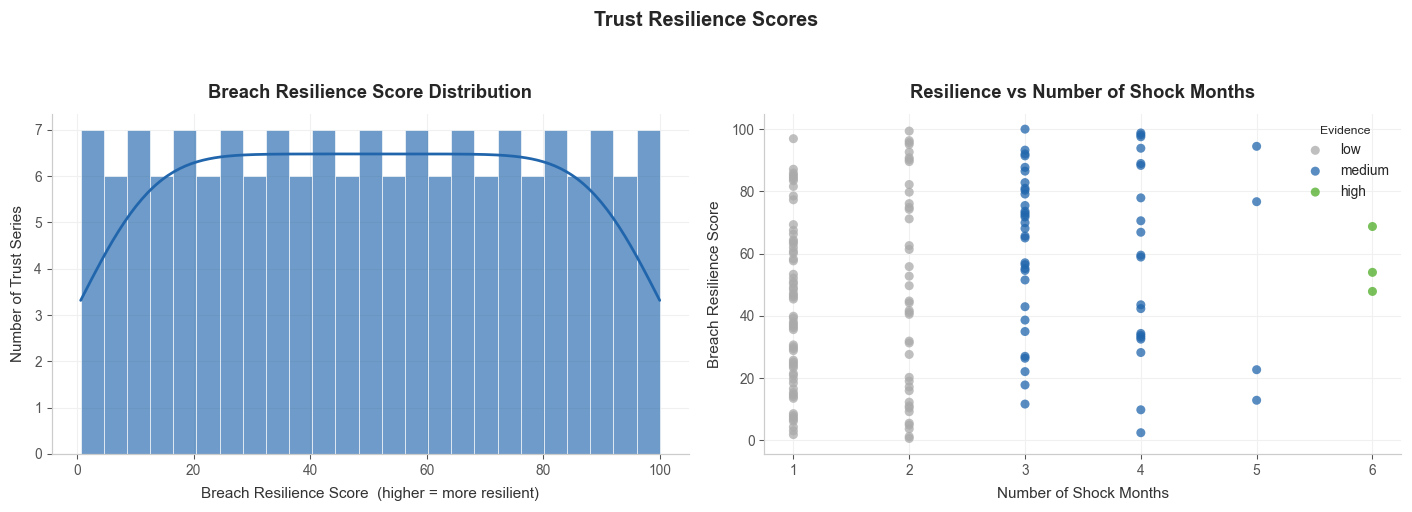

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Trust Resilience Scores", fontsize=13, fontweight="bold", y=1.03)

# ── Score distribution with KDE ──
ax = axes[0]
sns.histplot(
    trust_res["resilience_score"], bins=25, ax=ax,
    color=C_BLUE, alpha=0.65, kde=True,
    line_kws={"linewidth": 1.8, "color": C_BLUE},
    edgecolor="white", linewidth=0.4,
)
ax.set_title("Breach Resilience Score Distribution")
ax.set_xlabel("Breach Resilience Score  (higher = more resilient)")
ax.set_ylabel("Number of Trust Series")
legend = ax.get_legend()
if legend:
    legend.remove()

# ── Resilience vs shock count, coloured by evidence ──
ax = axes[1]
for ev in ["low", "medium", "high"]:
    grp = trust_res[trust_res["evidence_strength"].astype(str) == ev]
    if len(grp):
        ax.scatter(
            grp["n_shocks"], grp["resilience_score"],
            color=EVIDENCE_PALETTE[ev], alpha=0.75,
            edgecolors="none", s=35, label=ev,
        )
ax.set_title("Resilience vs Number of Shock Months")
ax.set_xlabel("Number of Shock Months")
ax.set_ylabel("Breach Resilience Score")
ax.legend(title="Evidence", title_fontsize=8)

fig.tight_layout()
plt.show()

## 6. Trust Clustering

K-means on **k = 3** using two features that directly capture the research question:

- `shrunk_breach_impact` — how much worse (or better) did the trust perform during shocks (James-Stein shrunk)
- `mean_demand_zscore_capped` — how intense were the demand shocks the trust faced

Note: the original unfiltered dataset gave silhouette 0.41 at k=2 and ~0.22 for k=3–6, strongly favouring k=2. After filtering to acute providers and correcting the feature set, the silhouette landscape shifts: k=3 scores 0.473 vs 0.411 for k=2. The filtering itself changed the cluster structure.

**Excluded from features:** trust size (`avg_attendances`), shock frequency (`n_shocks`), and structural break share — these are context descriptors, not response measures. Including them caused the original solution to sort mainly by size and data-quality artefacts.

Trusts with any remaining structural break months are excluded. Only medium/high evidence series (≥ 3 shock months) are clustered.

In [12]:
df_clust = pd.read_csv(RESILIENCE_PATH)

# medium/high evidence only; no structural break contamination
df_clust = df_clust[
    df_clust["evidence_strength"].isin(["medium", "high"]) &
    (df_clust["structural_break_share"] == 0)
].copy()

# features: response measure + shock intensity context only
features = [
    "shrunk_breach_impact",
    "mean_demand_zscore_capped",
]
df_clust = df_clust.dropna(subset=features).copy()
X_scaled = StandardScaler().fit_transform(df_clust[features])

print(f"Trust series available for clustering: {len(df_clust)}")

print("\nSilhouette scores (k = 2–6):")
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
    print(f"  k={k}: {silhouette_score(X_scaled, labels):.3f}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
df_clust["cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = [
    "resilience_score",
    "shrunk_breach_impact",
    "mean_demand_zscore_capped",
    "mean_demand_zscore",
    "avg_attendances_during_shock",
    "n_shocks",
]
cluster_profile = df_clust.groupby("cluster")[profile_cols].mean().round(4)
cluster_profile.insert(0, "n_trusts", df_clust["cluster"].value_counts().sort_index())

print(f"\nCluster profiles (k={N_CLUSTERS}):")
print(cluster_profile.to_string())

# label by shrunk_breach_impact rank: lowest impact = most resilient
impact_rank = cluster_profile["shrunk_breach_impact"].rank()
label_map = {}
for c in cluster_profile.index:
    r = impact_rank[c]
    if r == 1:
        label_map[c] = "resilient"
    elif r == cluster_profile.shape[0]:
        label_map[c] = "fragile"
    else:
        label_map[c] = "moderate"
df_clust["cluster_label"] = df_clust["cluster"].map(label_map)

df_clust.to_csv(CLUSTERS_PATH, index=False)
print(f"\nSaved  {CLUSTERS_PATH.name}")

for lbl in ["resilient", "moderate", "fragile"]:
    sub = df_clust[df_clust["cluster_label"] == lbl]
    if len(sub):
        print(f"\nTop 5 {lbl}:")
        print(
            sub.sort_values("resilience_score", ascending=(lbl == "fragile"))
            [["provider_name", "resilience_score", "shrunk_breach_impact", "n_shocks"]]
            .head(5).to_string(index=False)
        )

Trust series available for clustering: 59

Silhouette scores (k = 2–6):
  k=2: 0.411
  k=3: 0.473
  k=4: 0.390
  k=5: 0.404
  k=6: 0.401

Cluster profiles (k=3):
         n_trusts  resilience_score  shrunk_breach_impact  mean_demand_zscore_capped  mean_demand_zscore  avg_attendances_during_shock  n_shocks
cluster                                                                                                                                         
0              11           63.6921                0.0003                     3.2690              3.3414                    11966.1742    3.4545
1              35           46.9939                0.0043                     2.4400              2.4400                    11741.8519    3.7429
2              13           92.0717               -0.0096                     2.6167              2.6344                    13518.4744    3.4615

Saved  trust_resilience_clusters.csv

Top 5 resilient:
                                     provider_name  resil

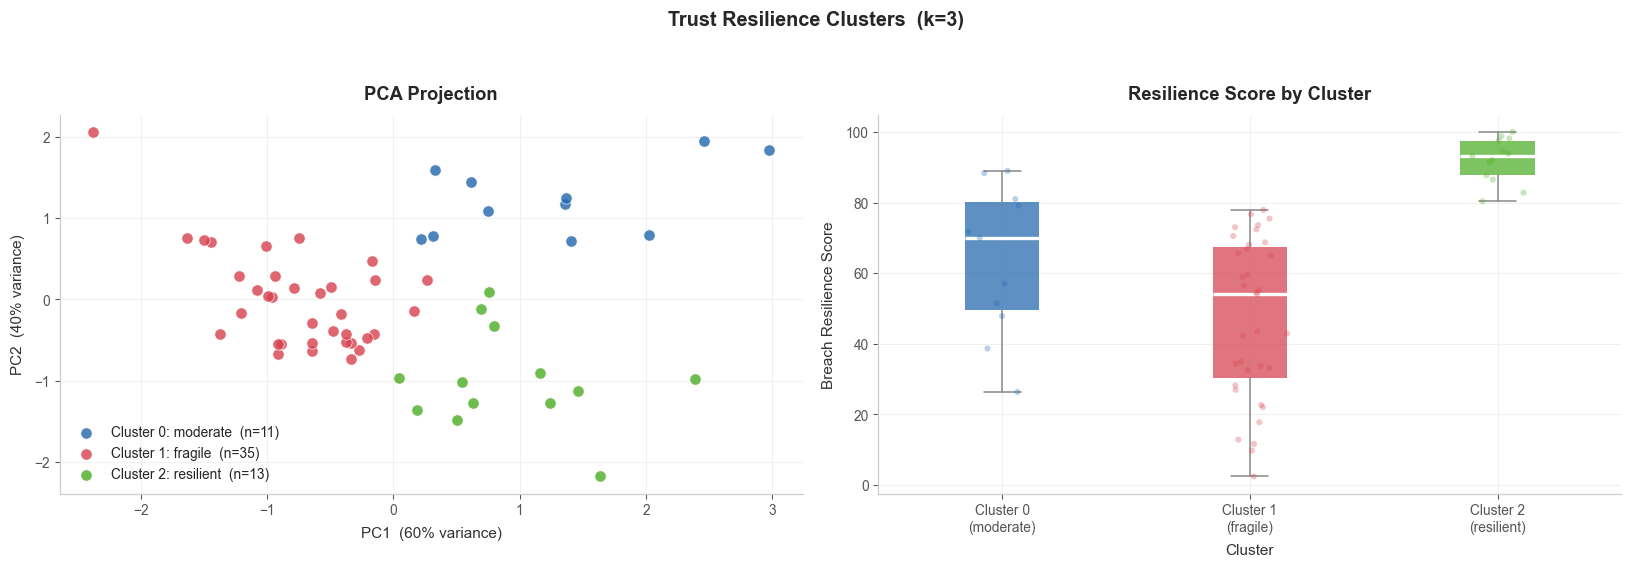

In [13]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_clust["pca1"] = coords[:, 0]
df_clust["pca2"] = coords[:, 1]

cluster_ids    = sorted(df_clust["cluster"].unique())
cluster_colors = [C_BLUE, C_RED, C_GREEN]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Trust Resilience Clusters  (k={N_CLUSTERS})", fontsize=13, fontweight="bold", y=1.03)

# ── PCA scatter ──
ax = axes[0]
for c in cluster_ids:
    sub   = df_clust[df_clust["cluster"] == c]
    label = sub["cluster_label"].iloc[0]
    ax.scatter(
        sub["pca1"], sub["pca2"],
        label=f"Cluster {c}: {label}  (n={len(sub)})",
        color=cluster_colors[c], alpha=0.8,
        edgecolors="white", linewidth=0.5, s=55,
    )
ax.set_title("PCA Projection")
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend(fontsize=9)

# ── Boxplot with individual point jitter ──
ax = axes[1]
cluster_data = [df_clust[df_clust["cluster"] == c]["resilience_score"].values for c in cluster_ids]
tick_labels  = [
    f"Cluster {c}\n({df_clust[df_clust['cluster'] == c]['cluster_label'].iloc[0]})"
    for c in cluster_ids
]

bp = ax.boxplot(
    cluster_data, patch_artist=True,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(linewidth=1.0, color="#888888"),
    capprops=dict(linewidth=1.0, color="#888888"),
    flierprops=dict(marker="o", markersize=3, alpha=0.35, markeredgewidth=0),
    boxprops=dict(linewidth=0),
)
for patch, c in zip(bp["boxes"], cluster_ids):
    patch.set_facecolor(cluster_colors[c])
    patch.set_alpha(0.72)

rng = np.random.default_rng(42)
for i, c in enumerate(cluster_ids):
    y = df_clust[df_clust["cluster"] == c]["resilience_score"].values
    x = rng.normal(i + 1, 0.07, size=len(y))
    ax.scatter(x, y, color=cluster_colors[c], alpha=0.30, s=16, edgecolors="none", zorder=3)

ax.set_title("Resilience Score by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Breach Resilience Score")
ax.set_xticklabels(tick_labels)

fig.tight_layout()
plt.show()